---
### Part 01 - load initial raw data
---

In [111]:
# import libs
from glob import glob
import os
import lasio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [21]:
# list dir
os.listdir("../data/las")

['AAM-4.las',
 'ALR-4.las',
 'ALR-16.las',
 'TFT-13.las',
 'AAM-10.las',
 'ALR-21.las',
 'ISL-19.las',
 'AAM-14.las',
 'HR-17.las',
 'HR-4.las',
 'AAM-18.las',
 'EMK-1.las',
 'BRK-1.las',
 'AAM-21.las',
 'OUR-2.las',
 'ISL-10.las',
 'HR-13.las',
 'TFT-14.las',
 'TFT-4.las',
 'AAM-6.las',
 'ALR-18.las',
 'ALR-9.las',
 'ISL-8.las',
 'HR-10.las',
 'HR-16.las',
 'ALR-17.las',
 'ALR-13.las',
 'AAM-8.las',
 'HR-7.las',
 'ALR-15.las',
 'TFT-5.las',
 'ISL-2.las',
 'TFT-11.las',
 'ISL-22.las',
 'ISL-13.las',
 'ISL-4.las',
 'ALR-19.las',
 'AAM-1.las',
 'TFT-1.las',
 'AAM-19.las',
 'ISL-16.las',
 'ALR-2.las',
 'GT-2.las',
 'HR-6.las',
 'HMD-5.las',
 'AAM-3.las',
 'ISL-18.las',
 'HR-1.las',
 'HR-2.las',
 'TFT-3.las',
 'MZL-1.las',
 'ALR-6.las',
 'TFT-2.las',
 'HR-11.las',
 'ISL-17.las',
 'AAM-5.las',
 'ALR-11.las',
 'BRK-2.las',
 'GT-1.las',
 'ELG-1.las',
 'ZRZ-1.las',
 'ZRZ-2.las',
 'TFT-12.las',
 'ELG-2.las',
 'GT-3.las',
 'AAM-17.las',
 'TFT-9.las',
 'ALR-5.las',
 'ISL-6.las',
 'ISL-11.las',
 '

In [22]:
# locate folder las
las_path = "../data/las"

In [23]:
# list las files
las_files = glob(f"{las_path}/*.las")
len(las_files)

83

In [24]:
# read one well first
las = lasio.read(las_files[0])
las.header

{'Version': [HeaderItem(mnemonic="VERS", unit="", value="2.0", descr=""),
  HeaderItem(mnemonic="WRAP", unit="", value="NO", descr="")],
 'Well': [HeaderItem(mnemonic="STRT", unit="m", value="155.09970504", descr=""),
  HeaderItem(mnemonic="STOP", unit="m", value="2250.0", descr=""),
  HeaderItem(mnemonic="STEP", unit="m", value="0.152", descr=""),
  HeaderItem(mnemonic="NULL", unit="", value="-999.25", descr=""),
  HeaderItem(mnemonic="COMP", unit="", value="SONATRACH", descr="COMPANY"),
  HeaderItem(mnemonic="WELL", unit="", value="AAM-4", descr="WELL"),
  HeaderItem(mnemonic="FLD", unit="", value="Ain Amenas", descr="FIELD"),
  HeaderItem(mnemonic="LOC", unit="", value="Algeria, Lat: 28.120, Lon: 9.525", "),
  HeaderItem(mnemonic="SRVC", unit="", value="Baker Hughes", descr="SERVICE COMP"),
  HeaderItem(mnemonic="DATE", unit="", value="2018-12-16 00:00:00   : Log Export"),
  HeaderItem(mnemonic="PROV", unit="", value="Sahara Central", descr="PROVINCE"),
  HeaderItem(mnemonic="UWI", 

In [28]:
# convert to pandas dataframe
df = las.df().reindex()
df.head()

,LITHOLOGY_CONFIDENCE,LITHOLOGY_CLASS,CALI,MUDWEIGHT,ROP,RDEP,RSHA,RMED,DTC,NPHI,PEF,GR,RHOB,DRHO,DEPTH_MD,X_LOC,Y_LOC,Z_LOC
DEPT,,,,,,,,,,,,,,,,,,
155.099705,NaN,NaN,NaN,NaN,14.689068,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
155.251705,NaN,NaN,NaN,NaN,14.670721,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
155.403705,NaN,NaN,NaN,NaN,14.652373,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
155.555705,NaN,NaN,NaN,NaN,14.634027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
155.707705,NaN,NaN,NaN,NaN,14.615680,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
### Part 02 - standardize the data
---

In [49]:
# load all the wells together
dfs = []

for file in las_files:

    las = lasio.read(file)

    df = las.df().reset_index()

    # print(type(df))   # class 'pandas.DataFrame'
    # print(df.columns)

    df.columns = [c.upper() for c in df.columns]

    # well name
    # print(file)    # ../data/las/AAM-4.las
    well = file.split("/")[-1].replace(".las", "")
    # print(well)     # AAM-4

    # region name
    region = well.split("-")[0]
    # print(region)    # AM

    df["WELL"] = well
    df["REGION"] = region

    # print(df.head())

    dfs.append(df)

final_df = pd.concat(dfs, ignore_index=True)


In [50]:
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1638107 entries, 0 to 1638106
Data columns (total 29 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   DEPT                  1638107 non-null  float64
 1   LITHOLOGY_CONFIDENCE  851658 non-null   float64
 2   LITHOLOGY_CLASS       844039 non-null   float64
 3   CALI                  882147 non-null   float64
 4   MUDWEIGHT             221139 non-null   float64
 5   ROP                   882925 non-null   float64
 6   RDEP                  1535469 non-null  float64
 7   RSHA                  502830 non-null   float64
 8   RMED                  1417942 non-null  float64
 9   DTC                   1139307 non-null  float64
 10  NPHI                  607362 non-null   float64
 11  PEF                   506252 non-null   float64
 12  GR                    1603270 non-null  float64
 13  RHOB                  830620 non-null   float64
 14  DRHO                  765164 non-null   float

In [57]:
final_df.describe()

,DEPT,LITHOLOGY_CONFIDENCE,LITHOLOGY_CLASS,CALI,MUDWEIGHT,ROP,RDEP,RSHA,RMED,DTC,...,Y_LOC,Z_LOC,BS,DTS,RXO,RMIC,SP,SGR,DCAL,ROPA
count,1.638107e+06,851658.000000,844039.000000,882147.000000,221139.000000,882925.000000,1.535469e+06,502830.000000,1.417942e+06,1.139307e+06,...,1.538097e+06,1.538097e+06,1.096224e+06,314118.000000,184438.000000,215362.000000,687634.000000,41921.000000,211900.000000,627884.000000
mean,1.876861e+03,1.171018,61714.064817,12.683615,14.336344,439.497073,1.014219e+01,11.337729,4.746521e+00,1.145272e+02,...,6.706163e+06,-1.877706e+03,1.375157e+01,220.132792,-47.969024,9.432302,45.874226,62.320908,9.387180,37.669995
std,1.066126e+03,0.458186,13877.216662,3.572450,44.517034,3547.567194,1.025613e+02,105.359657,6.137791e+01,3.173884e+01,...,1.323480e+05,1.014427e+03,5.103290e+00,82.534531,342.736271,98.429793,74.281951,63.344105,292.584426,91.646967
min,4.880000e-02,1.000000,30000.000000,2.340806,0.127016,-21.495783,1.000000e-04,0.056584,-8.418695e-03,0.000000e+00,...,6.406641e+06,-5.435889e+03,6.000000e+00,79.327354,-999.900024,0.056586,-400.000000,-983.000000,-7.911209,-999.250122
25%,1.003194e+03,1.000000,65000.000000,9.085900,0.161766,14.722836,9.315748e-01,0.825328,9.204937e-01,8.984405e+01,...,6.591174e+06,-2.601157e+03,9.875000e+00,157.653992,0.706932,0.907435,24.724890,27.747322,0.099576,15.285406
50%,1.759820e+03,1.000000,65000.000000,12.409645,1.102403,28.597115,1.407801e+00,1.343230,1.380060e+00,1.120304e+02,...,6.771062e+06,-1.770935e+03,1.225000e+01,197.519257,1.483171,1.646600,48.753498,73.179337,0.395277,25.798542
75%,2.625954e+03,1.000000,65030.000000,14.004926,1.404611,46.939632,2.308210e+00,2.611515,2.238813e+00,1.414047e+02,...,6.803076e+06,-1.054253e+03,1.750000e+01,260.159294,4.021766,4.129066,74.839558,94.457108,0.992176,39.121716
max,5.479040e+03,3.000000,99000.000000,32.111065,185.730927,92429.164063,1.999887e+03,2193.904541,1.999948e+03,2.409352e+02,...,6.856661e+06,-1.088560e+02,4.200000e+01,724.536194,35930.671875,6567.910156,280.842529,963.608582,10010.719727,3989.174316


In [56]:
final_df.isnull().mean().sort_values()

DEPT                    0.000000
WELL                    0.000000
REGION                  0.000000
GR                      0.021267
X_LOC                   0.061052
Y_LOC                   0.061052
DEPTH_MD                0.061052
Z_LOC                   0.061052
RDEP                    0.062656
RMED                    0.134402
DTC                     0.304498
BS                      0.330798
ROP                     0.461009
CALI                    0.461484
LITHOLOGY_CONFIDENCE    0.480096
LITHOLOGY_CLASS         0.484747
RHOB                    0.492939
DRHO                    0.532897
SP                      0.580226
ROPA                    0.616701
NPHI                    0.629229
PEF                     0.690953
RSHA                    0.693042
DTS                     0.808243
MUDWEIGHT               0.865003
RMIC                    0.868530
DCAL                    0.870643
RXO                     0.887408
SGR                     0.974409
dtype: float64

---
### Part 03 - data quality and data engineering
---

#### STEP 1 — Understanding the real schema
- discover all the existing curves

In [62]:
# discover all the existing curves
all_columns = set()

for df in dfs:
    all_columns.update(df.columns)

sorted(all_columns)


['BS',
 'CALI',
 'DCAL',
 'DEPT',
 'DEPTH_MD',
 'DRHO',
 'DTC',
 'DTS',
 'GR',
 'LITHOLOGY_CLASS',
 'LITHOLOGY_CONFIDENCE',
 'MUDWEIGHT',
 'NPHI',
 'PEF',
 'RDEP',
 'REGION',
 'RHOB',
 'RMED',
 'RMIC',
 'ROP',
 'ROPA',
 'RSHA',
 'RXO',
 'SGR',
 'SP',
 'WELL',
 'X_LOC',
 'Y_LOC',
 'Z_LOC']

#### STEP 2 — Frequency of the curves

Discover:

- which ones exist
- which ones are missing
- actual frequency

In [71]:
curve_counter = Counter()

for df in dfs:
    curve_counter.update(df.columns)

In [72]:
curve_df = (
    pd.DataFrame.from_dict(
        curve_counter,
        orient='index',
        columns=['count']
    )
    .sort_values('count', ascending=False)
)

curve_df

,count
DEPT,83
LITHOLOGY_CONFIDENCE,83
LITHOLOGY_CLASS,83
CALI,83
RDEP,83
NPHI,83
GR,83
DTC,83
WELL,83
Y_LOC,83


#### STEP 3 — Standardize names

In [73]:
# create a map
COLUMN_MAPPING = {
    "DEPT": "DEPTH",
    "DEPTH_MD": "DEPTH",
    "NPHI": "NPOR",
    "ILD": "RDEP",
}

In [78]:
# apply names
for i, df in enumerate(dfs):

    df.rename(
        columns=COLUMN_MAPPING,
        inplace=True
    )

    dfs[i] = df

#### STEP 4 — Missing values

- Now find the rate of nulls

In [82]:
missing = (
    final_df.isnull()
    .mean()
    .sort_values(ascending=False)    
)

missing

SGR                     0.974409
RXO                     0.887408
DCAL                    0.870643
RMIC                    0.868530
MUDWEIGHT               0.865003
DTS                     0.808243
RSHA                    0.693042
PEF                     0.690953
NPHI                    0.629229
ROPA                    0.616701
SP                      0.580226
DRHO                    0.532897
RHOB                    0.492939
LITHOLOGY_CLASS         0.484747
LITHOLOGY_CONFIDENCE    0.480096
CALI                    0.461484
ROP                     0.461009
BS                      0.330798
DTC                     0.304498
RMED                    0.134402
RDEP                    0.062656
Z_LOC                   0.061052
Y_LOC                   0.061052
X_LOC                   0.061052
DEPTH_MD                0.061052
GR                      0.021267
DEPT                    0.000000
REGION                  0.000000
WELL                    0.000000
dtype: float64

#### STEP 5 — Invalid values
LAS typically includes:
* -999.25
* -999.0
* -9999

In [86]:
# Change everything
INVALID_VALUES = [
    -999.25,
    -999.0,
    -9999,
    -99999
]

final_df.replace(
    INVALID_VALUES,
    np.nan,
    inplace=True
)

,DEPT,LITHOLOGY_CONFIDENCE,LITHOLOGY_CLASS,CALI,MUDWEIGHT,ROP,RDEP,RSHA,RMED,DTC,...,WELL,REGION,BS,DTS,RXO,RMIC,SP,SGR,DCAL,ROPA
0,155.099705,NaN,NaN,NaN,NaN,14.689068,NaN,NaN,NaN,NaN,...,AAM-4,AAM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,155.251705,NaN,NaN,NaN,NaN,14.670721,NaN,NaN,NaN,NaN,...,AAM-4,AAM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,155.403705,NaN,NaN,NaN,NaN,14.652373,NaN,NaN,NaN,NaN,...,AAM-4,AAM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,155.555705,NaN,NaN,NaN,NaN,14.634027,NaN,NaN,NaN,NaN,...,AAM-4,AAM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,155.707705,NaN,NaN,NaN,NaN,14.615680,NaN,NaN,NaN,NaN,...,AAM-4,AAM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638102,4311.415000,3.0,NaN,6.0,NaN,NaN,NaN,NaN,NaN,NaN,...,ISL-5,ISL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1638103,4311.567000,3.0,NaN,6.0,NaN,NaN,NaN,NaN,NaN,NaN,...,ISL-5,ISL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1638104,4311.719000,3.0,NaN,6.0,NaN,NaN,NaN,NaN,NaN,NaN,...,ISL-5,ISL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1638105,4311.871000,3.0,NaN,6.0,NaN,NaN,NaN,NaN,NaN,NaN,...,ISL-5,ISL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### STEP 6 — Remove duplicates

In [88]:
# verify
final_df.duplicated().sum()

np.int64(0)

In [89]:
# remove
final_df.drop_duplicates(inplace=True)

#### STEP 7 — View physical ranges

NOW the real petrophysics begins

#### **GR** 
Gamma Ray, measures the natural radioactivity of the formation

typical range 0–200

Mede a radioatividade natural da formação, normalmente em API ou gAPI, e é usada principalmente para indicar conteúdo de argila/folhelho.

Na prática:

- GR baixo costuma indicar rocha mais limpa, como arenito limpo ou carbonato
- GR alto costuma indicar mais argila ou folhelho

Uso comum:

- separar zonas limpas de zonas argilosas
- ajudar na correlação entre poços
- estimar Vsh (volume de argila)

Importante: GR alto não significa sempre argila; minerais radioativos também podem elevar a curva.

In [94]:
final_df["GR"].describe()

count    1.603270e+06
mean     7.314973e+01
std      3.921800e+01
min     -1.562818e+01
25%      4.787486e+01
50%      6.977029e+01
75%      9.114016e+01
max      1.141292e+03
Name: GR, dtype: float64

**Observation:**

In general:

- Negative GR: physically, not expected for raw gamma ray in API
- 0 to 200 API: is a fairly common range, but not a hard limit
- max = 1141: this seems very suspicious for conventional GR
- min = -15.6: also seems suspicious

My reading of result is:

- mean ~ 73, median ~ 70, P25 ~ 48, P75 ~ 91:
this seems plausible for a real GR set

- std ~ 39:
normal dispersion for data with a mixture of clean and clayey zones

- negative min and very high max: strong signal of outliers, QC problem, different unit, profile correction, or bad value coming from some well/section

About typical range:

- clean sandstones/carbonates: often low, something like 10–50 API
- shales/clayeys: often 80–150+ API
- Above 200 is possible, but 1141 is significantly outside the norm and warrants inspection.

**Conclusion:** 

The core of the distribution looks good, but the tails seem contaminated. I would address these extremes before using GR for analysis, modeling, or Vsh calculation.

---
---

In [118]:
# mask = (final_df["GR"] < 0) | (final_df["GR"] > 300)
# estranhos = final_df[mask]

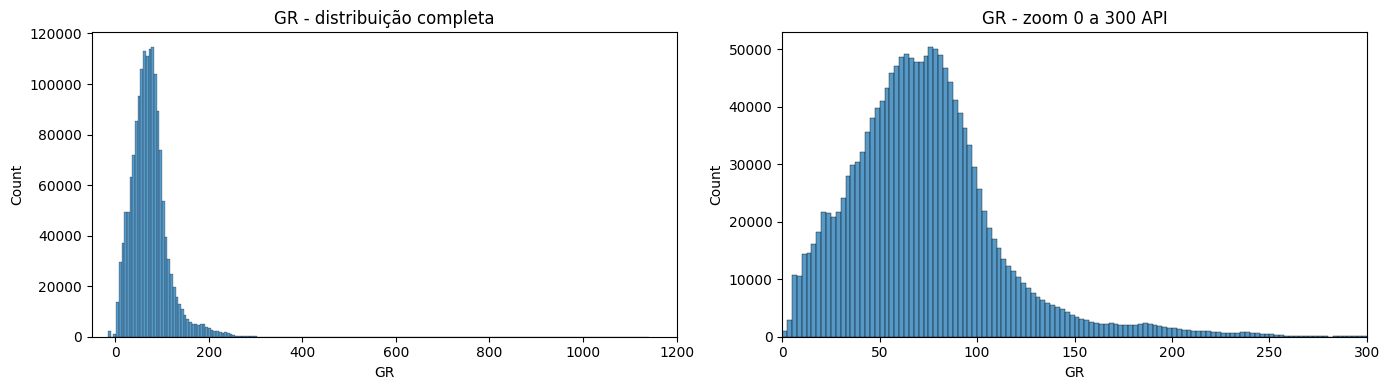

In [119]:
# 1. Histograma do todo + zoom no intervalo normal
# Isso mostra se o problema está só na cauda ou se há mais de uma população.
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(final_df["GR"].dropna(), bins=200, ax=ax[0])
ax[0].set_title("GR - distribuição completa")
ax[0].set_xlim(-50, 1200)

sns.histplot(final_df.loc[final_df["GR"].between(0, 300), "GR"].dropna(), bins=120, ax=ax[1])
ax[1].set_title("GR - zoom 0 a 300 API")
ax[1].set_xlim(0, 300)

plt.tight_layout()
plt.show()

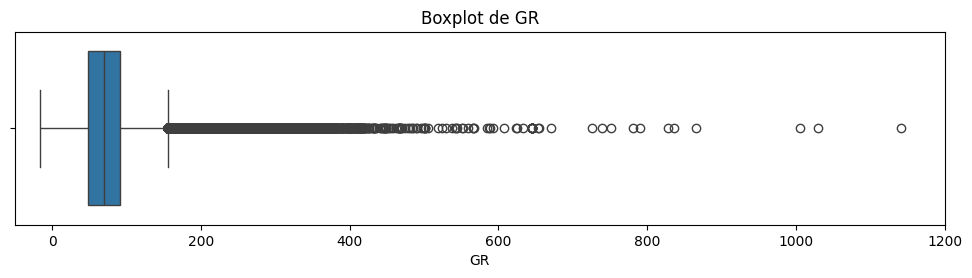

In [120]:
# 2. Boxplot para evidenciar outliers
# Se os pontos extremos estiverem muito longe da caixa, reforça a hipótese de valor ruim.
plt.figure(figsize=(12, 2.5))
sns.boxplot(x=final_df["GR"].dropna())
plt.xlim(-50, 1200)
plt.title("Boxplot de GR")
plt.show()

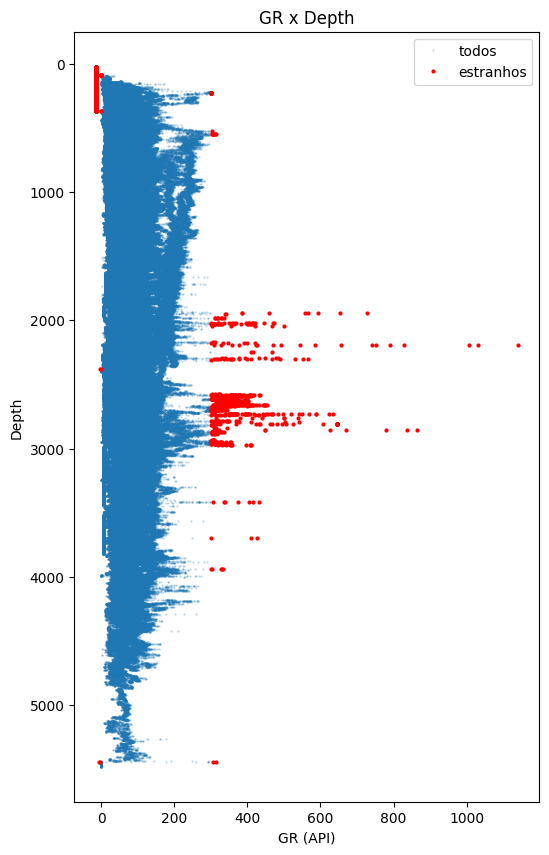

In [121]:
# 3. GR por profundidade, marcando os estranhos
mask = (final_df["GR"] < 0) | (final_df["GR"] > 300)
estranhos = final_df[mask]

plt.figure(figsize=(6, 10))

plt.plot(final_df["GR"], final_df["DEPT"], ".", ms=1, alpha=0.3, label="todos")
plt.plot(estranhos["GR"], estranhos["DEPT"], "r.", ms=4, label="estranhos")

plt.gca().invert_yaxis()
plt.xlabel("GR (API)")
plt.ylabel("Depth")
plt.title("GR x Depth")
plt.legend()
plt.show()


**Análise dos Gráficos**:
Os gráficos reforçam a leitura de que o miolo do GR parece plausível, mas a cauda está contaminada.

No boxplot, a maior parte dos dados parece concentrada mais ou menos na faixa esperada de GR, com caixa perto de algo como 40–100 API e whiskers indo até algo em torno de 150. O problema é a cauda direita muito longa, com muitos pontos acima disso e alguns chegando perto de 1100+. Para GR convencional em gAPI, isso é bem suspeito.

No GR x Depth, o ponto principal é que os valores estranhos não estão distribuídos aleatoriamente. Eles aparecem concentrados em certos intervalos de profundidade, principalmente algo como:

* ~1900–2400
* ~2600–3000
* alguns poucos rasos perto do topo
* alguns negativos isolados

Isso sugere mais problema localizado do que comportamento natural da curva. Pode ser:

* um ou poucos poços específicos
* intervalo com curva mal calibrada
* mistura de curvas/unidades diferentes
* valores inválidos que não foram limpos
* saturação/falha de ferramenta ou problema de merge

Um detalhe importante: como você juntou vários poços em final_df, esse gráfico de profundidade agregado pode enganar. Dois pontos no mesmo DEPT podem ser de poços diferentes. Então o próximo passo certo é identificar quais poços geram esses outliers.

Os gráficos mostram que o problema existe de verdade, não parece só impressão do describe(), e os outliers parecem estruturados por intervalo/poço. Eu não usaria GR bruto assim para modelagem antes de fazer esse QC. 


#### **RHOB** 
RHOB, measures the volumetric density of the formation

typical range 1.8–3.0

RHOB é a curva de Bulk Density, ou densidade volumétrica da formação, normalmente em g/cm³.

Ela mede a densidade aparente da rocha no subsolo, incluindo:

- matriz da rocha
- fluidos nos poros

Uso comum:

- estimar porosidade
- ajudar a identificar litologia
- combinar com NPHI para detectar gás ou diferenciar rochas
- apoiar cálculos petrofísicos

Leitura prática:

- RHOB baixo tende a indicar mais porosidade, gás, ou rochas menos densas
- RHOB alto tende a indicar rochas mais compactas/densas, menos porosas, ou minerais pesados

Faixas típicas, de forma bem geral:

- arenitos: cerca de 2.0–2.65
- calcários: cerca de 2.3–2.71
- dolomitos: cerca de 2.4–2.87
Mas o valor observado depende bastante de:

- porosidade
- fluido
- argila
- invasão
- condição do poço

In [123]:
final_df['RHOB'].describe()

count    830620.000000
mean          2.255459
std           0.440408
min           0.000000
25%           2.120915
50%           2.345750
75%           2.502161
max           3.457820
Name: RHOB, dtype: float64

Minha leitura: o miolo da distribuição de RHOB parece plausível, mas os extremos merecem QC.

- 25% = 2.12, 50% = 2.35, 75% = 2.50: isso faz sentido para um conjunto misto de rochas sedimentares com porosidade variando.
- mean = 2.26 menor que a mediana = 2.35: sinal de cauda baixa puxando a média para baixo.
- min = 0.0: isso é praticamente certo que é valor inválido / placeholder, não densidade real.
- max = 3.46: é bem alto para bulk density de formações sedimentares comuns. Não é impossível, mas é suspeito e eu investigaria.

Faixas de referência bem gerais:

- arenito quartzoso: matriz perto de 2.65
- calcário: 2.71
- dolomita: 2.87
- anidrita: 2.98

Então:

- valores entre ~2.1 e 2.5 são bem compatíveis com rochas porosas/argilosas/saturadas
- 0.0 deve ser tratado como NaN
- acima de 3.0 eu colocaria como suspeito até provar o contrário

O std = 0.44 está um pouco largo, mas isso pode acontecer se você juntou muitos poços/litologias e ainda tem valores ruins misturados.

In [125]:
final_df["RHOB"].eq(0).sum()
final_df["RHOB"].quantile([0.001, 0.01, 0.05, 0.95, 0.99, 0.999])

mask = (final_df["RHOB"] <= 1.5) | (final_df["RHOB"] >= 3.0)
# final_df.loc[mask, ["WELL", "DEPT", "RHOB"]].head(50)

Total com RHOB válido: 830,620
Estranhos: 26,767 (3.22%)


/tmp/ipykernel_1869587/3978714544.py:49: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/wolf/.pyenv/versions/wolf-petrophysics-analitics/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


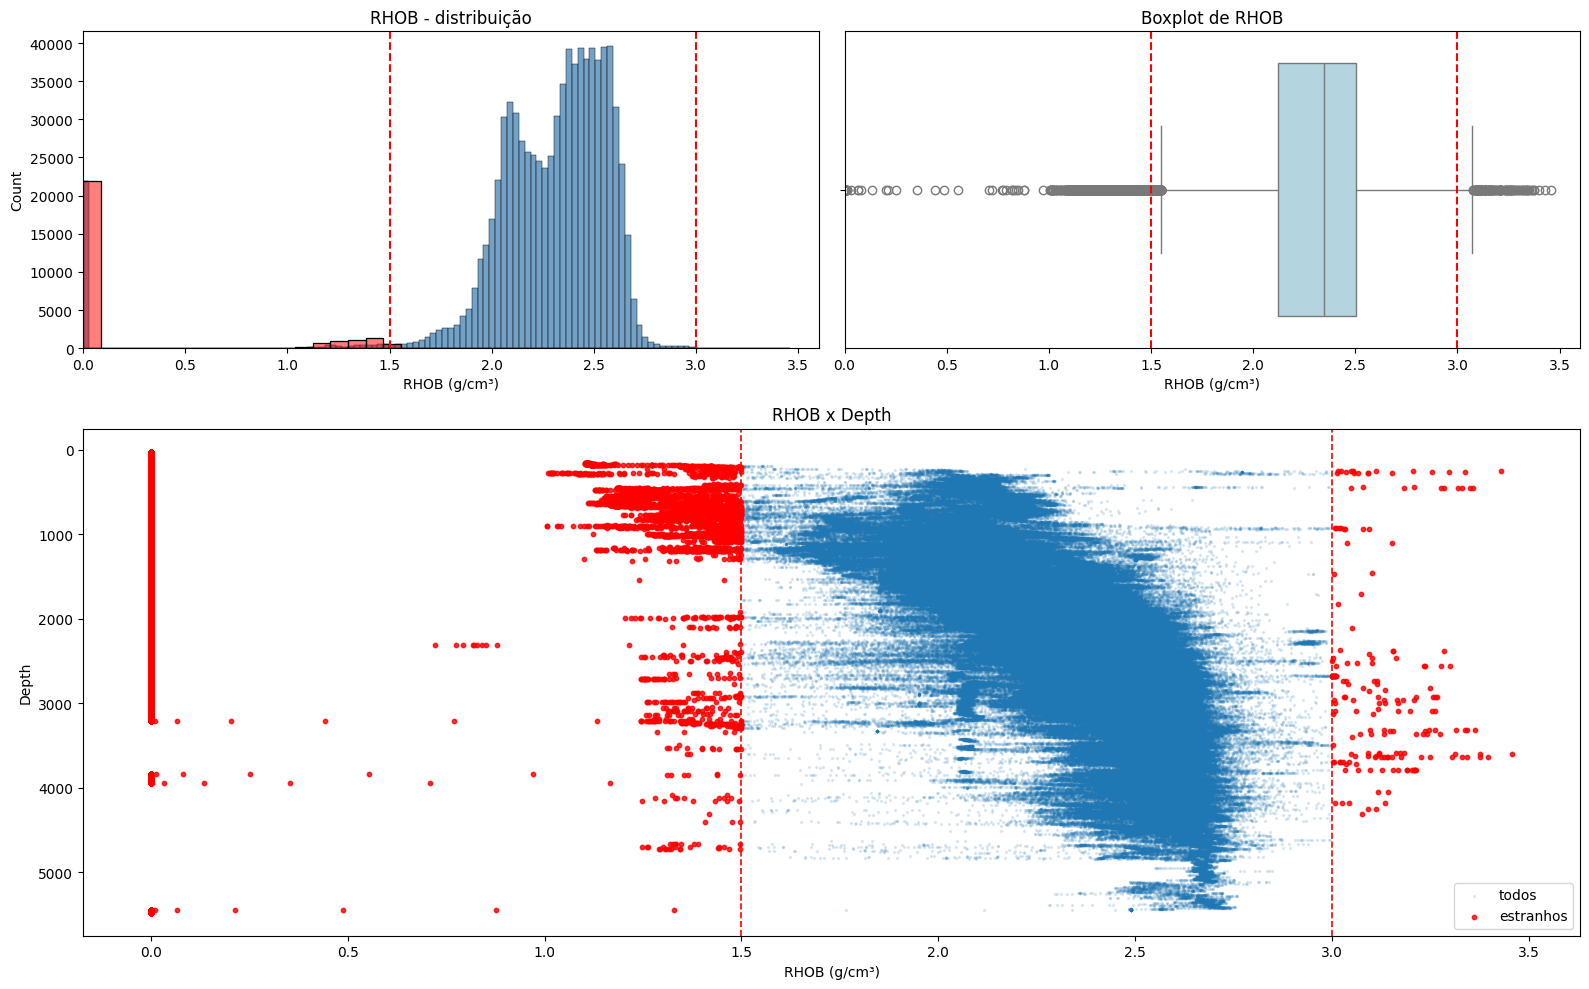

In [126]:
# Colunas necessárias
plot_df = final_df[["DEPT", "RHOB"]].dropna().copy()

# Limites iniciais de QC para RHOB
rhob_min = 1.5
rhob_max = 3.0

mask = (plot_df["RHOB"] <= rhob_min) | (plot_df["RHOB"] >= rhob_max)
estranhos = plot_df.loc[mask].copy()

print(f"Total com RHOB válido: {len(plot_df):,}")
print(f"Estranhos: {len(estranhos):,} ({len(estranhos)/len(plot_df):.2%})")

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.6])

# 1. Histplot
ax1 = fig.add_subplot(gs[0, 0])
sns.histplot(plot_df["RHOB"], bins=120, color="steelblue", ax=ax1)
sns.histplot(estranhos["RHOB"], bins=40, color="red", alpha=0.5, ax=ax1)
ax1.axvline(rhob_min, color="red", linestyle="--", linewidth=1.5)
ax1.axvline(rhob_max, color="red", linestyle="--", linewidth=1.5)
ax1.set_title("RHOB - distribuição")
ax1.set_xlabel("RHOB (g/cm³)")
ax1.set_ylabel("Count")
ax1.set_xlim(0, 3.6)

# 2. Boxplot
ax2 = fig.add_subplot(gs[0, 1])
sns.boxplot(x=plot_df["RHOB"], ax=ax2, color="lightblue")
ax2.axvline(rhob_min, color="red", linestyle="--", linewidth=1.5)
ax2.axvline(rhob_max, color="red", linestyle="--", linewidth=1.5)
ax2.set_title("Boxplot de RHOB")
ax2.set_xlabel("RHOB (g/cm³)")
ax2.set_xlim(0, 3.6)

# 3. RHOB por profundidade
ax3 = fig.add_subplot(gs[1, :])
ax3.scatter(plot_df["RHOB"], plot_df["DEPT"], s=2, alpha=0.12, label="todos")
ax3.scatter(estranhos["RHOB"], estranhos["DEPT"], s=10, color="red", alpha=0.8, label="estranhos")
ax3.axvline(rhob_min, color="red", linestyle="--", linewidth=1.2)
ax3.axvline(rhob_max, color="red", linestyle="--", linewidth=1.2)
ax3.invert_yaxis()
ax3.set_title("RHOB x Depth")
ax3.set_xlabel("RHOB (g/cm³)")
ax3.set_ylabel("Depth")
ax3.legend()

plt.tight_layout()
plt.show()


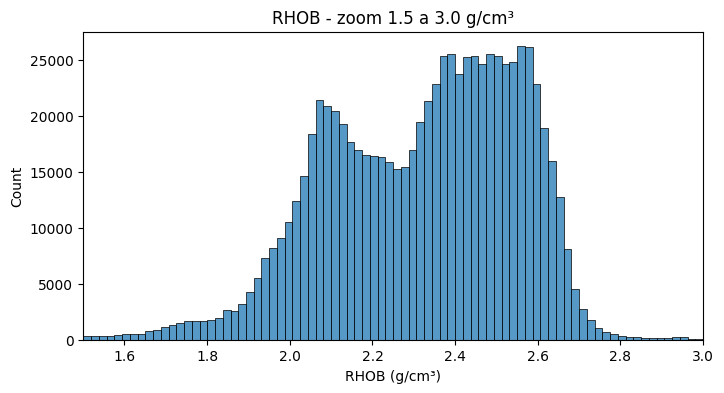

In [127]:
plt.figure(figsize=(8, 4))
sns.histplot(plot_df.loc[plot_df["RHOB"].between(1.5, 3.0), "RHOB"], bins=80)
plt.title("RHOB - zoom 1.5 a 3.0 g/cm³")
plt.xlabel("RHOB (g/cm³)")
plt.xlim(1.5, 3.0)
plt.show()


Minha leitura é que os gráficos de RHOB contam uma história bem mais clara que os de GR.

O centro da distribuição parece plausível, mas há dois problemas distintos:

- uma massa de valores 0.0, que quase certamente é valor inválido / missing mal codificado
- uma cauda alta > 3.0 g/cm³, que é rara e precisa ser investigada

No histograma completo, o pico em 0.0 não parece geológico. Isso é típico de:

- preenchimento com zero
- erro de importação
- curva ausente em parte dos poços

- No RHOB x Depth, isso fica ainda mais forte: há uma “coluna” vermelha em RHOB = 0 atravessando um intervalo grande de profundidade. Isso parece muito mais um artefato de dado do que resposta real da formação.

Sobre a parte “boa” da curva, no zoom 1.5 a 3.0, eu diria que há pelo menos 2 componentes sobrepostos:

- uma população em torno de ~2.0–2.15
- outra, mais dominante, em torno de ~2.35–2.6

Então, diferente do GR, aqui eu vejo sim sinal de bimodalidade ou pelo menos um ombro forte separando dois grupos. Isso pode ser mistura de:

- litologias diferentes
- níveis de porosidade diferentes
- poços diferentes
- zonas lavadas / má qualidade de leitura em parte dos dados

Os valores > 3.0 aparecem em bandas de profundidade e não totalmente aleatórios, então eu suspeitaria de:

- alguns poços específicos
- intervalos específicos
- possível problema de calibração/unidade/merge
- mais do que um comportamento global do dataset.

Resumo prático:

- RHOB = 0.0: eu trataria como NaN
- 1.5–3.0: parece a faixa útil principal
- dentro dessa faixa, há indício de 2 populações
- ">3.0": manter como suspeito até checar por poço e profundidade

#### **DTC** 
DTC, Compressional Sonic Transit Time

typical range 40–200 us/ft

Ela mede o tempo de trânsito da onda sonora compressional pela formação, normalmente em:

- us/ft (microsegundos por pé)
- às vezes us/m

Interpretação prática:

- DTC baixo = onda viaja mais rápido, isso costuma indicar rocha mais compacta, mais rígida, menos porosa
- DTC alto = onda viaja mais devagar, isso costuma indicar mais porosidade, rocha menos consolidada, presença de fluido/gás, ou argila

Usos comuns:

- estimativa de porosidade sônica
- apoio à identificação litológica
- integração com sísmica
- detecção de zonas anômalas, fraturas ou gás
- cálculos geomecânicos e de velocidade

Cuidado:

- DTC depende de litologia, porosidade, fluido e condição do poço
- lama, washout e má qualidade do perfil podem distorcer a leitura

In [129]:
final_df['DTC'].describe()

count    1.139307e+06
mean     1.145272e+02
std      3.173884e+01
min      0.000000e+00
25%      8.984405e+01
50%      1.120304e+02
75%      1.414047e+02
max      2.409352e+02
Name: DTC, dtype: float64

Minha leitura: o miolo do DTC parece razoável, mas os extremos precisam de QC.

DTC muito provavelmente está em us/ft, porque os quartis fazem sentido nessa unidade.

O que os números sugerem:

- 25% = 89.8, 50% = 112.0, 75% = 141.4: faixa bem compatível com um conjunto misto de rochas, incluindo intervalos mais argilosos/porosos.
- mean = 114.5 e mediana = 112.0: leve assimetria à direita, ou seja, há uma cauda de valores altos puxando a média.
- std = 31.7: dispersão relativamente grande, mas plausível se você juntou muitos poços/litologias.
- min = 0.0: isso é quase certamente valor inválido ou missing mal codificado.
- max = 240.9: é alto e suspeito. Pode existir em intervalos muito problemáticos, mal condicionados, muito inconsolidados ou com má qualidade de perfil, mas eu não aceitaria sem investigar.

Resumo prático:

- o centro da distribuição parece crível
- 0.0 eu trataria como NaN
- valores muito altos, por exemplo > 200 us/ft, eu marcaria como suspeitos

**Análise Gráfica**

Para DTC, eu começaria com uma regra conservadora:

- DTC == 0 → inválido
- DTC < 40 → muito suspeito
- DTC > 200 → suspeito, mas não necessariamente erro

-------------------------------------------------------------------------------
Total com DTC válido: 1,139,307
Estranhos: 9,924 (0.87%)
DTC == 0: 9,039
-------------------------------------------------------------------------------


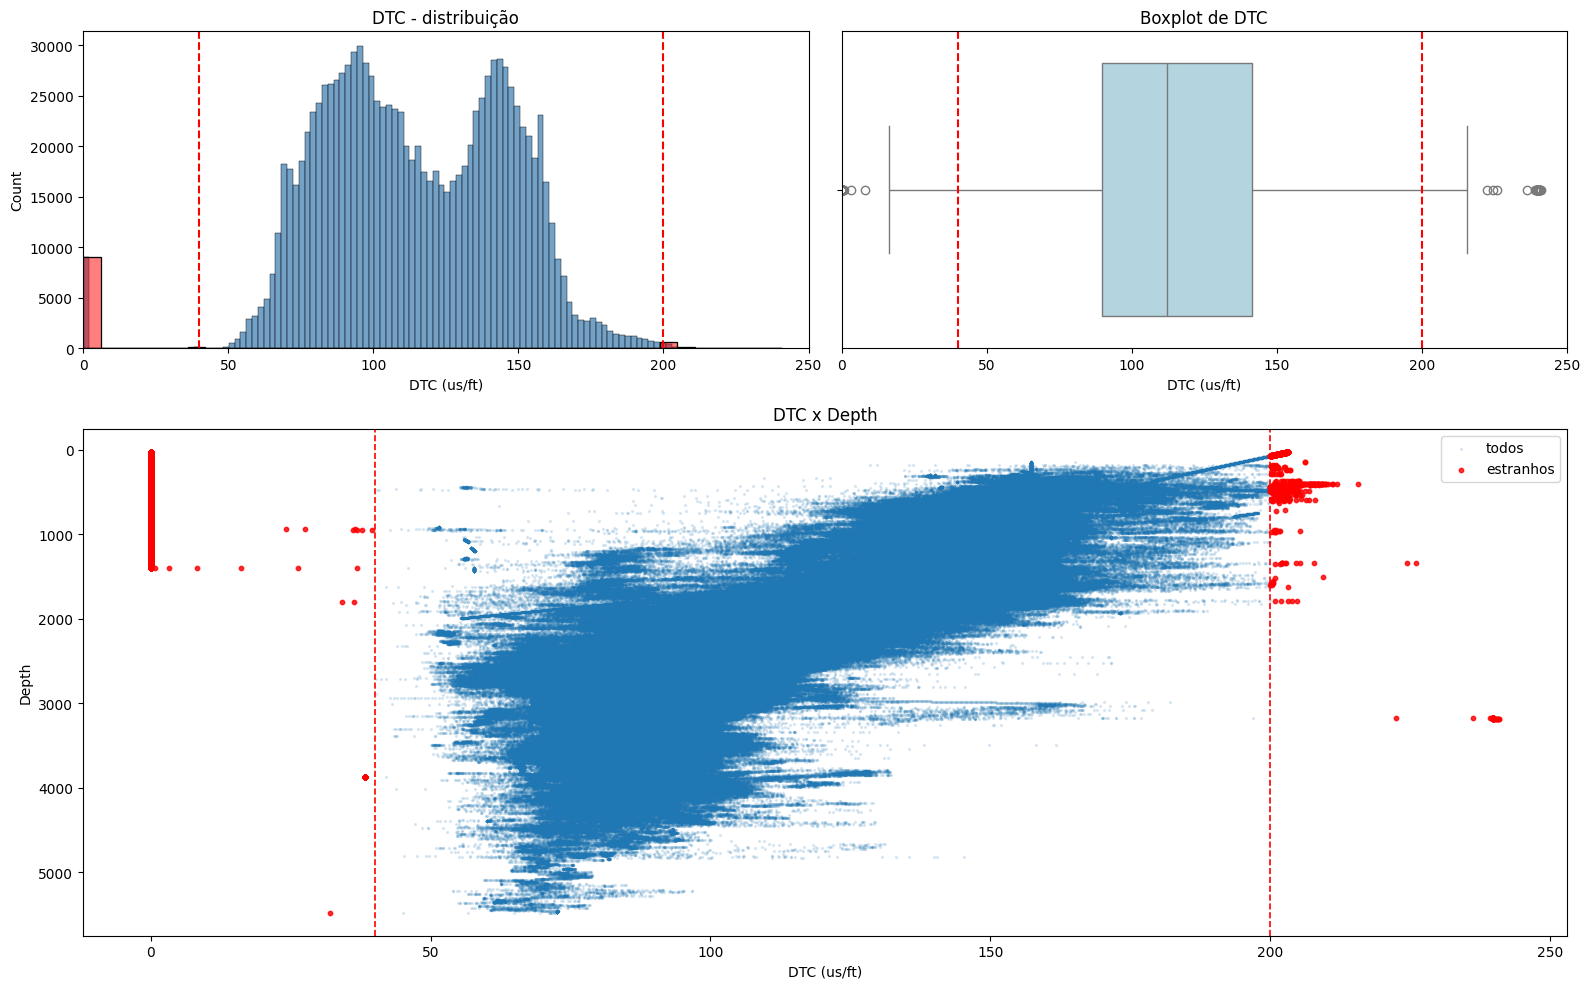

In [134]:
# Colunas necessárias
plot_df = final_df[["DEPT", "DTC"]].dropna().copy()

# Limites iniciais de QC para DTC
dtc_min = 40
dtc_max = 200

# Máscara de estranhos
mask = (plot_df["DTC"] <= dtc_min) | (plot_df["DTC"] >= dtc_max)
estranhos = plot_df.loc[mask].copy()

print("-------------------------------------------------------------------------------")
print(f"Total com DTC válido: {len(plot_df):,}")
print(f"Estranhos: {len(estranhos):,} ({len(estranhos)/len(plot_df):.2%})")
print(f"DTC == 0: {(plot_df['DTC'] == 0).sum():,}")
print("-------------------------------------------------------------------------------")

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.6])

# 1. Histplot
ax1 = fig.add_subplot(gs[0, 0])
sns.histplot(plot_df["DTC"], bins=120, color="steelblue", ax=ax1)
sns.histplot(estranhos["DTC"], bins=40, color="red", alpha=0.5, ax=ax1)
ax1.axvline(dtc_min, color="red", linestyle="--", linewidth=1.5)
ax1.axvline(dtc_max, color="red", linestyle="--", linewidth=1.5)
ax1.set_title("DTC - distribuição")
ax1.set_xlabel("DTC (us/ft)")
ax1.set_ylabel("Count")
ax1.set_xlim(0, 250)

# 2. Boxplot
ax2 = fig.add_subplot(gs[0, 1])
sns.boxplot(x=plot_df["DTC"], ax=ax2, color="lightblue")
ax2.axvline(dtc_min, color="red", linestyle="--", linewidth=1.5)
ax2.axvline(dtc_max, color="red", linestyle="--", linewidth=1.5)
ax2.set_title("Boxplot de DTC")
ax2.set_xlabel("DTC (us/ft)")
ax2.set_xlim(0, 250)

# 3. DTC por profundidade
ax3 = fig.add_subplot(gs[1, :])
ax3.scatter(plot_df["DTC"], plot_df["DEPT"], s=2, alpha=0.12, label="todos")
ax3.scatter(estranhos["DTC"], estranhos["DEPT"], s=10, color="red", alpha=0.8, label="estranhos")
ax3.axvline(dtc_min, color="red", linestyle="--", linewidth=1.2)
ax3.axvline(dtc_max, color="red", linestyle="--", linewidth=1.2)
ax3.invert_yaxis()
ax3.set_title("DTC x Depth")
ax3.set_xlabel("DTC (us/ft)")
ax3.set_ylabel("Depth")
ax3.legend()

plt.tight_layout()
plt.show()


O gráfico está coerente com o describe(): o miolo do DTC parece utilizável, mas há dois grupos de anomalia bem visíveis.

- DTC = 0 aparece como uma coluna vertical vermelha no DTC x Depth. Isso é quase certamente valor inválido / missing mal codificado, não resposta física da formação.

- A distribuição principal entre ~60 e 180 us/ft parece plausível.

- Há bimodalidade razoavelmente clara no histograma, com um pico perto de ~90–100 e outro perto de ~140–150 us/ft. Isso sugere mistura de populações, possivelmente litologias/porosidades/poços diferentes.

- Os valores > 200 us/ft existem, mas são poucos. Como aparecem concentrados sobretudo em zonas mais rasas, eles podem ser reais porém especiais e não necessariamente erro bruto.

- Os poucos valores < 40 us/ft também são suspeitos.

O DTC x Depth está interessante porque mostra um padrão geológico plausível no conjunto:

- em profundidades rasas, o DTC tende a ser mais alto
- em maiores profundidades, o DTC tende a cair
- isso combina com compactação da formação com a profundidade

Então a conclusão prática é:

- 0 deve virar NaN
- < 40 deve ser tratado como suspeito
- "> 200" deve ser flagged, mas não removido cegamente
- a distribuição útil do DTC parece ter 2 populações principais

Abaixo estão os poços concentram os valores suspeitos de DTC

In [136]:
mask_zero = final_df["DTC"] == 0
mask_high = final_df["DTC"] > 200
mask_low  = (final_df["DTC"] > 0) & (final_df["DTC"] < 40)

print("-------------------------------------------------------------------------------")
print(final_df.loc[mask_zero, "WELL"].value_counts().head(10))
print("-------------------------------------------------------------------------------")
print(final_df.loc[mask_high, "WELL"].value_counts().head(10))
print("-------------------------------------------------------------------------------")
print(final_df.loc[mask_low, "WELL"].value_counts().head(10))
print("-------------------------------------------------------------------------------")


-------------------------------------------------------------------------------
WELL
ISL-22    9039
Name: count, dtype: int64
-------------------------------------------------------------------------------
WELL
TFT-2     298
ISL-8     168
HR-17      96
HR-7       71
ALR-19     56
ISL-18     52
EMK-1      27
GT-3       23
ISL-11      6
ZRZ-1       3
Name: count, dtype: int64
-------------------------------------------------------------------------------
WELL
ISL-4     65
ISL-22     8
ISL-17     7
TFT-9      2
Name: count, dtype: int64
-------------------------------------------------------------------------------


Avaliação dos poços que concentram os valores suspeitos de DTC:

- DTC == 0: isso está praticamente todo concentrado em ISL-22 (9039 pontos). É o sinal mais forte de problema de dado até agora. Muito provavelmente essa curva está ausente, mal preenchida ou codificada com zero nesse poço. Eu trataria esses zeros como NaN e colocaria ISL-22 sob suspeita para DTC inteiro.

- DTC > 200: aqui o comportamento é diferente. Os valores estão espalhados em alguns poços específicos (TFT-2, ISL-8, HR-17, HR-7, ALR-19...), então isso parece anomalia localizada por poço/intervalo, não erro global do dataset. Parte disso pode ser real, parte pode ser QC ruim.

- 0 < DTC < 40: isso é raro e concentrado principalmente em ISL-4. Para DTC compressional em us/ft, essa faixa é bem suspeita. Eu trataria como valor ruim até prova em contrário.

Resumo prático:

- ISL-22: forte candidato a curva inválida de DTC.
- TFT-2, ISL-8, HR-17, HR-7: prioridade para inspeção dos DTC altos.
- ISL-4: prioridade para inspeção dos DTC muito baixos.

O ponto importante é que isso ainda é contagem bruta. O próximo passo certo é olhar percentual por poço, porque 298 pontos em um poço longo podem ser pouco, mas 9039 zeros em um poço só já é bem grave.

#### **RDEP** 
RDEP, Deep Resistivity

typical range 0.2–2000

RDEP normalmente é a curva de Deep Resistivity, ou resistividade profunda.

Ela mede a resistividade elétrica da formação em uma investigação mais profunda, tentando enxergar além da zona invadida pela lama. A unidade costuma ser ohm.m.

Interpretação prática:

- RDEP alto costuma indicar formação mais resistiva
isso pode estar associado a hidrocarboneto, baixa salinidade da água, rocha compacta ou baixa porosidade

- RDEP baixo costuma indicar formação mais condutiva
geralmente mais água salina e/ou mais argila

Uso comum:

- avaliação de saturação de água
- identificação de possíveis zonas com hidrocarboneto
- comparação com resistividades rasa/média (RSHA, RMED, etc.) para estudar invasão

Cuidado:

- resistividade depende de muita coisa:
  - saturação de água
  - salinidade da água
  - porosidade
  - argila
  - invasão

- então RDEP alto não significa automaticamente hidrocarboneto


In [137]:
final_df['RDEP'].describe()

count    1.535469e+06
mean     1.014219e+01
std      1.025613e+02
min      1.000000e-04
25%      9.315748e-01
50%      1.407801e+00
75%      2.308210e+00
max      1.999887e+03
Name: RDEP, dtype: float64

**Avaliação do resultado:* 

RDEP está com uma distribuição muito assimétrica à direita, o que é normal até certo ponto para resistividade, mas aqui os extremos parecem bem fortes.

O centro da distribuição:

- 25% = 0.93
- 50% = 1.41
- 75% = 2.31

isso sugere que a maior parte dos dados está em resistividades relativamente baixas a moderadas, o que é plausível em muitos intervalos com água e/ou argila.

O ponto importante é a diferença entre:

- mediana = 1.41
- média = 10.14
- std = 102.56

Isso mostra que a média está sendo puxada fortemente por uma cauda longa de valores altos. Em resistividade isso pode acontecer, porque a distribuição raramente é bem comportada em escala linear.

Avaliação dos extremos:

- min = 0.0001: muito baixo; pode até aparecer como piso instrumental, valor truncado ou placeholder. Eu investigaria.
- max = 1999.887: muito alto; pode ser real em alguns casos, mas também pode indicar censura no limite da ferramenta, saturação, ou valor especial.

Então:

- para RDEP, a mediana e os quantis são muito mais informativos que a média
eu não confiaria na interpretação da média como “valor típico”
eu provavelmente analisaria RDEP também em escala log

Resumo curto:

- o miolo parece plausível
- a distribuição é fortemente enviesada
- os extremos precisam de QC
- faz mais sentido analisar log10(RDEP) do que RDEP bruto

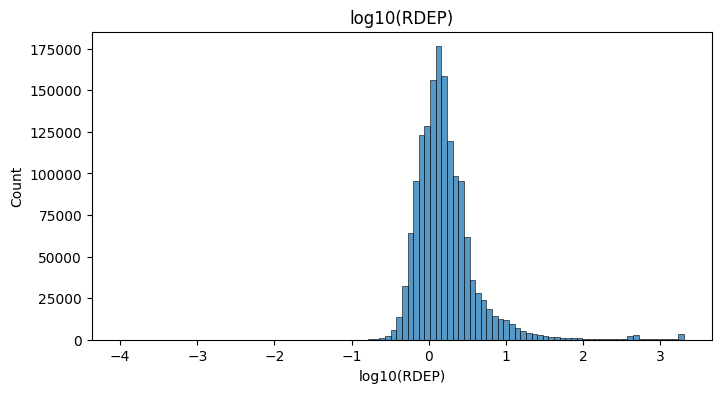

In [138]:
x = final_df["RDEP"].replace([0], np.nan).dropna()
x = x[x > 0]

plt.figure(figsize=(8,4))
sns.histplot(np.log10(x), bins=100)
plt.title("log10(RDEP)")
plt.xlabel("log10(RDEP)")
plt.show()


#### STEP 8 — Detect suspicious data

#### STEP 9 — Outliers

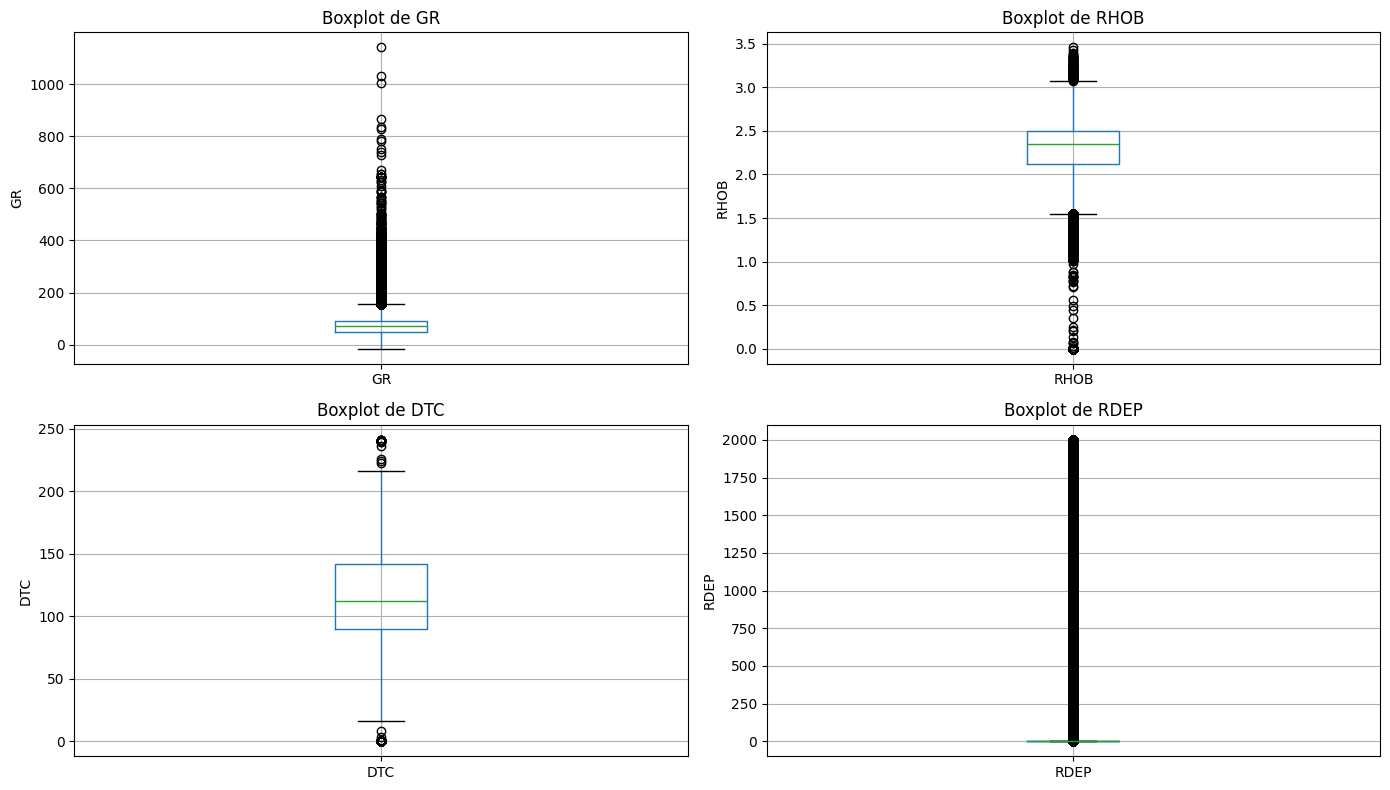

In [146]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

final_df.boxplot(column="GR", ax=axes[0, 0])
axes[0, 0].set_title("Boxplot de GR")
axes[0, 0].set_ylabel("GR")

final_df.boxplot(column="RHOB", ax=axes[0, 1])
axes[0, 1].set_title("Boxplot de RHOB")
axes[0, 1].set_ylabel("RHOB")

final_df.boxplot(column="DTC", ax=axes[1, 0])
axes[1, 0].set_title("Boxplot de DTC")
axes[1, 0].set_ylabel("DTC")

final_df.boxplot(column="RDEP", ax=axes[1, 1])
axes[1, 1].set_title("Boxplot de RDEP")
axes[1, 1].set_ylabel("RDEP")

plt.tight_layout()
plt.show()
